# Siamese Networks for few-shot learning

A Siamese network is a neural architecture that learns a similarity function instead of a direct classifier.

It consists of:

* Two (or more) identical subnetworks
* Shared weights
* A function that compares their outputs

Training objective is given by the following goal:

* similar inputs → close embeddings
* different inputs → far embeddings



In [1]:
import sys
sys.path.append('../../src')

In [2]:
from pathlib import Path

import joblib
import pandas as pd

data_dir = Path("../data")

print(f"Loading extracted features from {data_dir}.")
df_train = pd.read_parquet(data_dir / "malware_train.parquet")
df_val = pd.read_parquet(data_dir / "malware_val.parquet")
df_test = pd.read_parquet(data_dir / "malware_test.parquet")
df_train_label = pd.read_parquet(data_dir / "malware_train_labels.parquet")
df_val_label = pd.read_parquet(data_dir / "malware_val_labels.parquet")
df_test_label = pd.read_parquet(data_dir / "malware_test_labels.parquet")

preprocessor_path = data_dir / "malware_preprocessor.joblib"
if not preprocessor_path.exists():
    fallback_path = data_dir / "preprocessor.joblib"
    if not fallback_path.exists():
        raise FileNotFoundError(
            f"Could not find {preprocessor_path} or {fallback_path}. Run the data preparation notebook first."
        )
    print(f"{preprocessor_path.name} not found, using {fallback_path.name} instead.")
    preprocessor_path = fallback_path

preprocessor = joblib.load(preprocessor_path)
print(f"Loaded preprocessor from {preprocessor_path}.")

Loading extracted features from ../data.
Loaded preprocessor from ../data/malware_preprocessor.joblib.


In [4]:
df_x_train = preprocessor.transform(df_train)
df_x_val = preprocessor.transform(df_val)
df_x_test = preprocessor.transform(df_test)

label_to_id = {"system": 0, "unknown": 1, "malware": 2, "application":3}

df_y_train = df_train_label["connection_label"].map(label_to_id)
df_y_val = df_val_label["connection_label"].map(label_to_id)
df_y_test = df_test_label["connection_label"].map(label_to_id)

if df_y_train.isna().any() or df_y_val.isna().any() or df_y_test.isna().any():
    raise ValueError("Found unmapped connection_label values outside system/unknown/malware/application.")
display("Data preprocessed.")

'Data preprocessed.'

In [5]:
import torch

from tls_profiling.fewshot.siamese import run_siamese_few_shot

# x_train: [N_train, input_dim]
# y_train: [N_train]
# x_test:  [N_test, input_dim]
# y_test:  [N_test]

x_train = torch.as_tensor(df_x_train, dtype=torch.float32)
y_train = torch.as_tensor(df_y_train, dtype=torch.long)
x_test = torch.as_tensor(df_x_val, dtype=torch.float32)
y_test = torch.as_tensor(df_y_val, dtype=torch.long)

input_dim = x_train.shape[1]

model, results = run_siamese_few_shot(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    input_dim=input_dim,
    emb_dim=16,
    epochs=50,
    n_way=3,
    k_shot_values=(1, 5, 10),
    q_query=100,
    n_episodes=100,
    encoder="deep"
)

SiameseNetwork(
  (encoder): DeepEncoder(
    (net): Sequential(
      (0): Linear(in_features=157, out_features=256, bias=True)
      (1): ReLU()
      (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): ReLU()
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): Linear(in_features=128, out_features=64, bias=True)
      (8): ReLU()
      (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): Linear(in_features=64, out_features=16, bias=True)
    )
  )
)
Epoch 01 | loss = 0.2751
Epoch 02 | loss = 0.2207
Epoch 03 | loss = 0.1805
Epoch 04 | loss = 0.1599
Epoch 05 | loss = 0.1652
Epoch 06 | loss = 0.1597
Epoch 07 | loss = 0.1634
Epoch 08 | loss = 0.1577
Epoch 09 | loss = 0.1582
Epoch 10 | loss = 0.1550
Epoch 11 | loss = 0.1573
Epoch 12 | loss = 0.1595

In [6]:
from tls_profiling.fewshot.prototypes import build_prototypes, predict_with_prototypes

prototypes = build_prototypes(model.encoder, x_train, y_train)
display(prototypes)

{0: tensor([-0.1912,  0.1814,  0.1365, -0.3413,  0.0168,  0.0825,  0.3146,  0.2110,
         -0.3711, -0.3189, -0.0584,  0.5569, -0.1218,  0.1489,  0.2183, -0.0853]),
 1: tensor([-0.0317,  0.1840, -0.1444,  0.2368, -0.0220, -0.1251,  0.2668,  0.2827,
         -0.2241, -0.2550,  0.3488,  0.2069, -0.4444,  0.0411, -0.4305, -0.2386]),
 2: tensor([ 0.1781,  0.1602, -0.0998,  0.1826, -0.0777, -0.2222,  0.1537,  0.0992,
         -0.0911, -0.4558,  0.3025,  0.1818, -0.2539,  0.3386, -0.5206,  0.1404])}

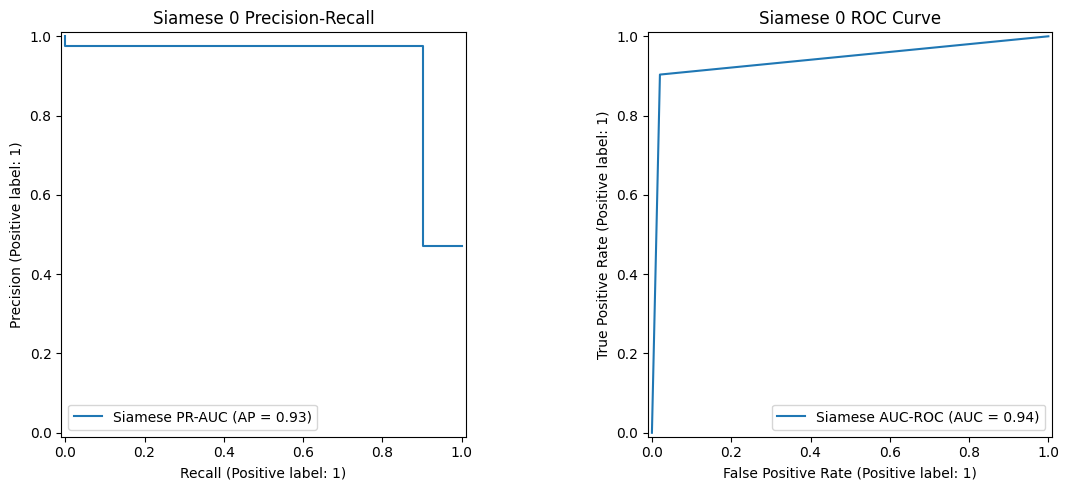

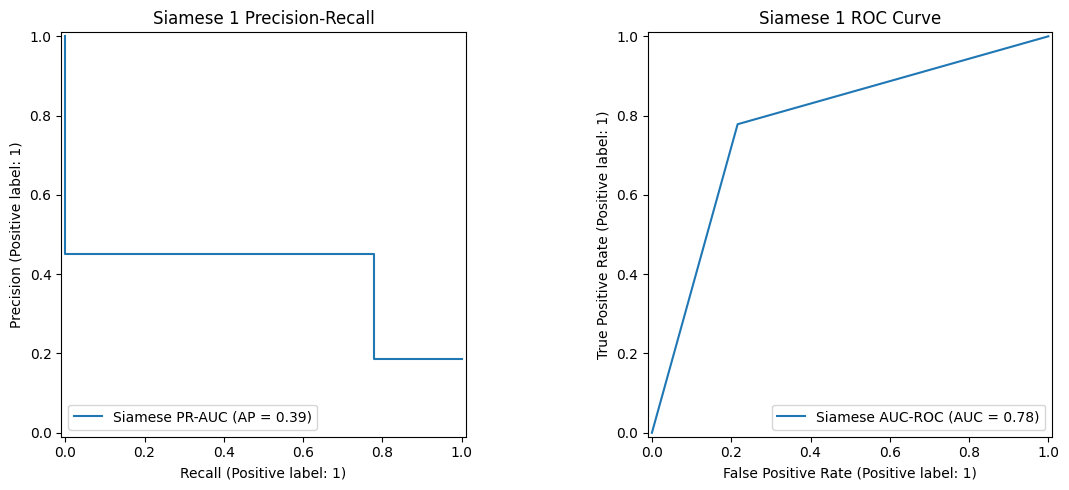

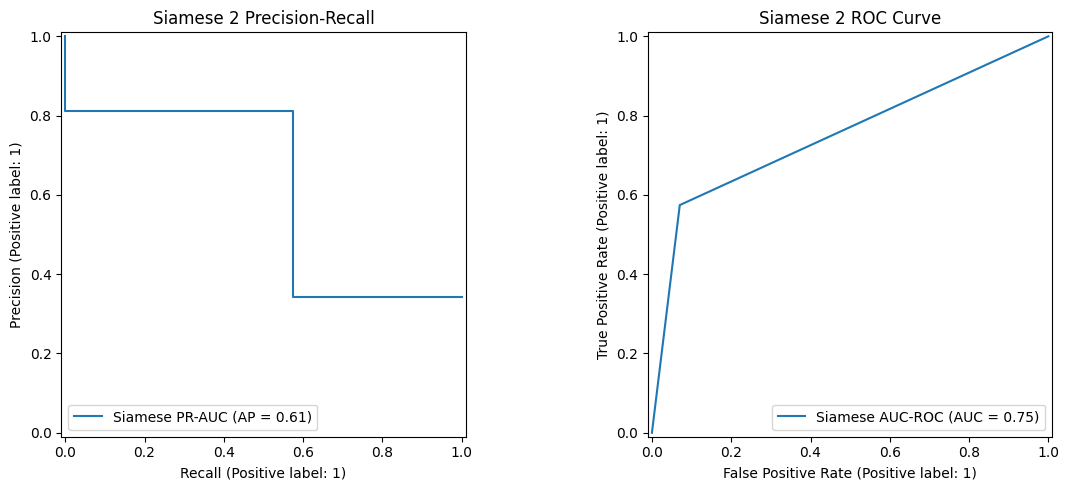

In [7]:
preds,_ = predict_with_prototypes(model.encoder, prototypes, x_test)

from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

import matplotlib.pyplot as plt


def make_binary(values, label):
    values = torch.as_tensor(values)
    return (values == label).to(dtype=torch.long)
def plot_curves(normal_label):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    PrecisionRecallDisplay.from_predictions(
        make_binary(y_test, normal_label),
        make_binary(preds,normal_label),
        name="Siamese PR-AUC",
        ax=axes[0],
    )
    axes[0].set_title(f"Siamese {normal_label} Precision-Recall")

    RocCurveDisplay.from_predictions(
        make_binary(y_test, normal_label),
        make_binary(preds,normal_label),
        name="Siamese AUC-ROC",
        ax=axes[1],
    )
    axes[1].set_title(f"Siamese {normal_label} ROC Curve")

    plt.tight_layout()
    plt.show()

for l in [0,1,2]:
    plot_curves(l)